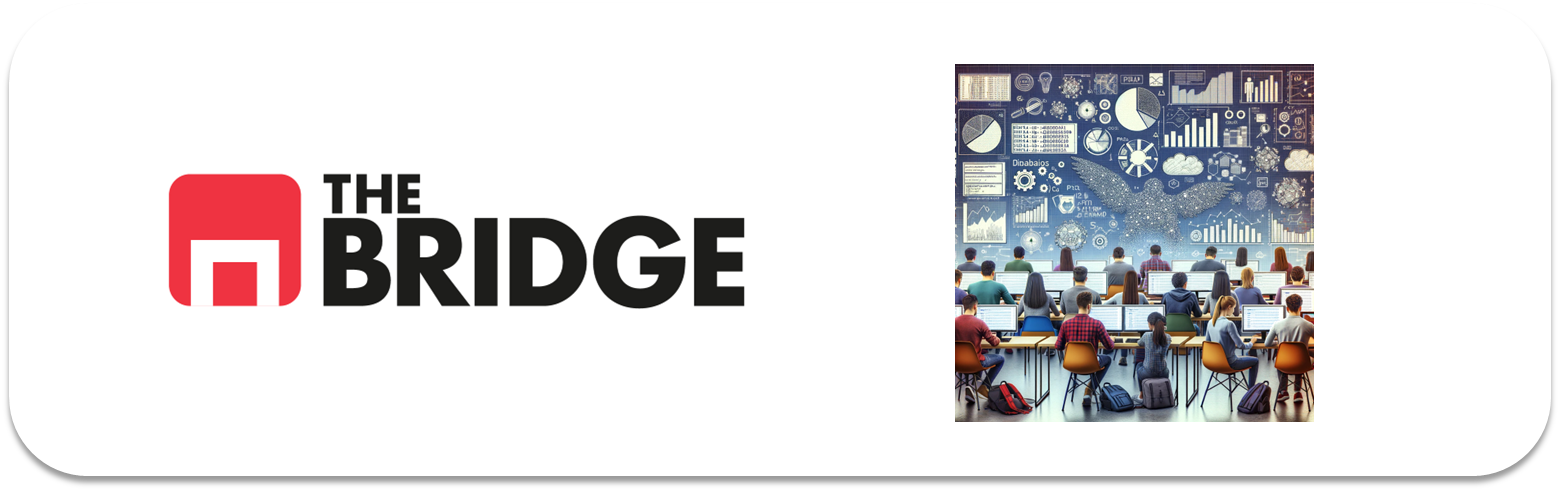

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descargar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



## 1. Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn import metrics, model_selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

## 2. Carga del dataset

El CSV viene separado por barras verticales (`|`), así que lo cargamos indicando ese separador. La variable objetivo será `MEDV`.

In [2]:
ruta_dataset = Path("data/hard_to_find/obligatoria_hard.csv")

# El fichero está separado por |.
df = pd.read_csv(ruta_dataset, sep="|")

print(f"Dataset cargado desde: {ruta_dataset}")
print(f"Dimensiones: {df.shape}")
df.head()

Dataset cargado desde: data\hard_to_find\obligatoria_hard.csv
Dimensiones: (506, 13)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


## 3. Revisión inicial y limpieza básica

Revisamos dimensiones, tipos, nulos y nombres de columnas.

In [3]:
print("Dimensiones:", df.shape)
display(df.head())
display(df.info())
display(df.describe().T)

Dimensiones: (506, 13)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


None

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [4]:
# Normalizamos los nombres de columnas a mayúsculas para evitar problemas.
df.columns = [str(col).strip().upper() for col in df.columns]

print("Columnas:")
print(df.columns.tolist())

print("\nNulos por columna:")
display(df.isnull().sum())

Columnas:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']

Nulos por columna:


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64

In [5]:
if "MEDV" in df.columns:
    target = "MEDV"
elif "TARGET" in df.columns:
    target = "TARGET"
else:
    raise ValueError("No encuentro la variable objetivo. Revisa si la columna se llama MEDV o TARGET.")

print("Target seleccionado:", target)

Target seleccionado: MEDV


## 4. Mini-EDA

Primero vemos la distribución del target y después analizamos correlaciones. Esto ayuda a detectar variables con más relación lineal con `MEDV`.

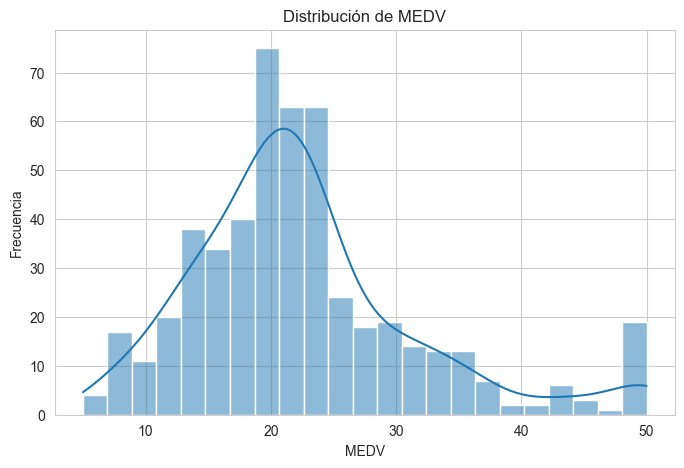

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df[target], kde=True)
plt.title(f"Distribución de {target}")
plt.xlabel(target)
plt.ylabel("Frecuencia")
plt.show()

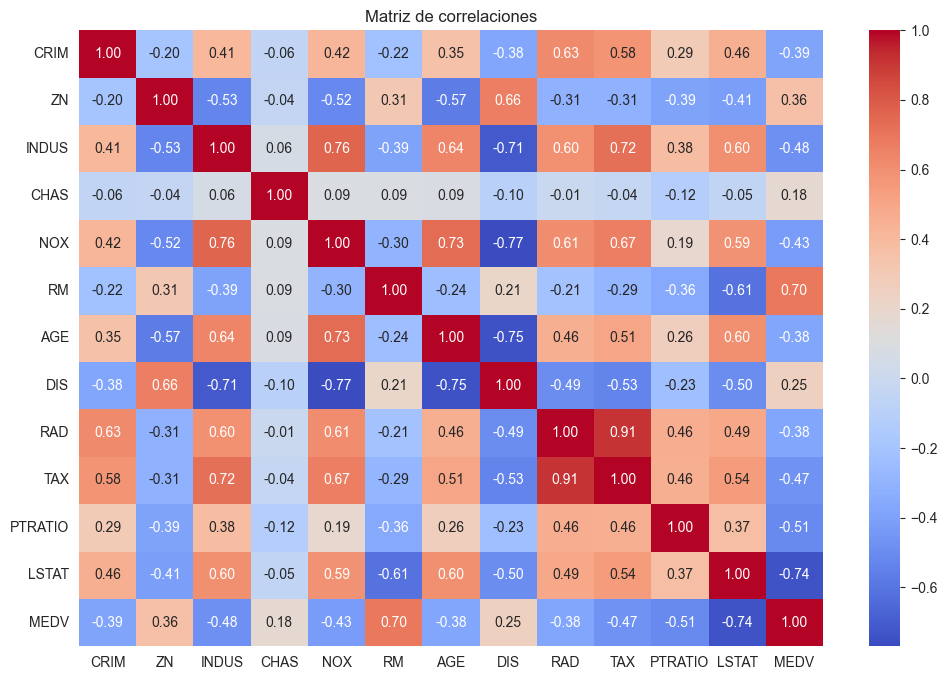

In [7]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlaciones")
plt.show()

In [8]:
correlaciones_target = (
    corr[target]
    .drop(target)
    .sort_values(key=lambda serie: abs(serie), ascending=False)
)

display(correlaciones_target.to_frame("correlación_con_target"))

,correlación_con_target
LSTAT,-0.737663
RM,0.695360
PTRATIO,-0.507787
INDUS,-0.483725
TAX,-0.468536
NOX,-0.427321
CRIM,-0.388305
RAD,-0.381626
AGE,-0.376955
ZN,0.360445


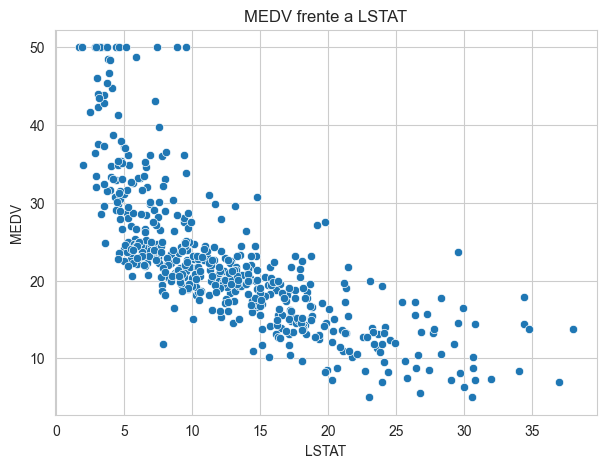

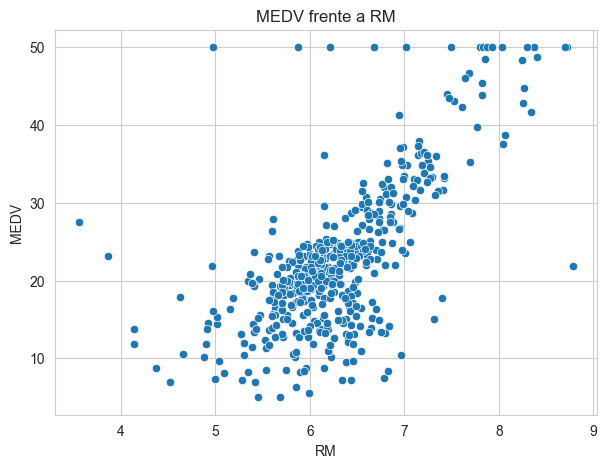

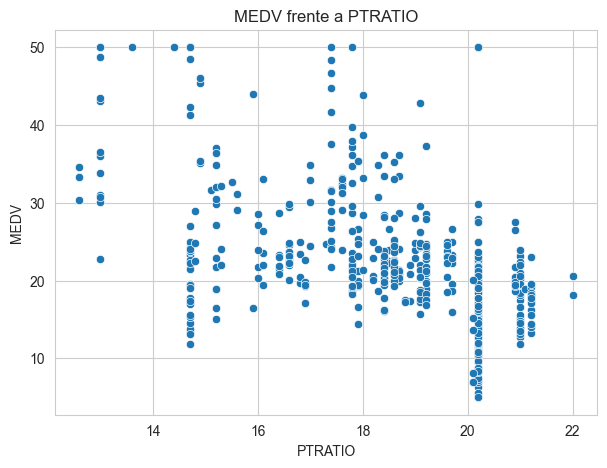

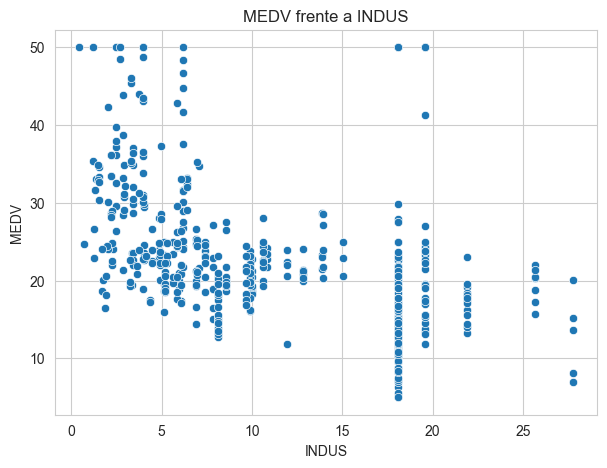

In [9]:
# Representamos las variables más correlacionadas con el target.
top_features = correlaciones_target.head(4).index.tolist()

for col in top_features:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=col, y=target)
    plt.title(f"{target} frente a {col}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

### Comentario EDA

A partir de la matriz de correlaciones, suelen destacar variables como:

- `LSTAT`: porcentaje de población de estatus socioeconómico bajo. Normalmente se relaciona negativamente con `MEDV`.
- `RM`: número medio de habitaciones. Normalmente se relaciona positivamente con `MEDV`.
- `PTRATIO`, `INDUS`, `TAX` o `NOX`: suelen tener relación negativa con el valor de la vivienda.

Para el primer modelo usaremos todas las variables predictoras disponibles porque todas describen características de la zona o la vivienda. Después, con los coeficientes, revisaremos qué variables pesan más en el modelo.

## 5. Selección de variables `X` e `y`

El target es `MEDV`. El resto de columnas serán features. 

In [10]:
X = df.drop(columns=[target])
y = df[target]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

display(X.head())
display(y.head())

Shape X: (506, 12)
Shape y: (506,)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33


0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64

## 6. Split en train y test

Reservamos una parte del dataset para test. Uso `random_state=42` para que los resultados sean reproducibles.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (404, 12)
X_test: (102, 12)
y_train: (404,)
y_test: (102,)


## 7. Tratamiento de variables

Las variables están en escalas muy diferentes: por ejemplo, `NOX` está entre 0 y 1, mientras que `TAX` puede estar en cientos. Por eso se aplica `StandardScaler`.

Aunque una regresión lineal sin regularización puede funcionar sin escalar, el escalado es especialmente importante para Ridge, Lasso y ElasticNet.

## 8. Función de evaluación

Se crea una función para evaluar todos los modelos con las mismas métricas:

- `MAE`: error absoluto medio.
- `MSE`: error cuadrático medio.
- `RMSE`: raíz del error cuadrático medio.
- `R2`: proporción de variabilidad explicada por el modelo.

In [12]:
def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    """Entrena un modelo y devuelve métricas de train y test."""

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultados = {
        "modelo": nombre,
        "MAE_train": metrics.mean_absolute_error(y_train, pred_train),
        "MAE_test": metrics.mean_absolute_error(y_test, pred_test),
        "MSE_train": metrics.mean_squared_error(y_train, pred_train),
        "MSE_test": metrics.mean_squared_error(y_test, pred_test),
        "RMSE_train": np.sqrt(metrics.mean_squared_error(y_train, pred_train)),
        "RMSE_test": np.sqrt(metrics.mean_squared_error(y_test, pred_test)),
        "R2_train": metrics.r2_score(y_train, pred_train),
        "R2_test": metrics.r2_score(y_test, pred_test),
    }

    return resultados, pred_train, pred_test

## 9. Modelo base: Regresión Lineal

In [13]:
modelo_lineal = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

resultado_lineal, pred_train_lineal, pred_test_lineal = evaluar_modelo(
    "LinearRegression",
    modelo_lineal,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([resultado_lineal])

,modelo,MAE_train,MAE_test,MSE_train,MSE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,LinearRegression,3.424469,3.111377,22.604286,22.777709,4.754397,4.7726,0.739802,0.689397


## 10. Comparación gráfica de predicciones y valores reales

,real,prediccion
0,23.6,28.958215
1,32.4,36.287541
2,13.6,14.098836
3,22.8,25.033144
4,16.1,17.601968
5,20.0,23.294368
6,17.8,17.414978
7,14.0,13.688916
8,19.6,22.037299
9,16.8,20.300903


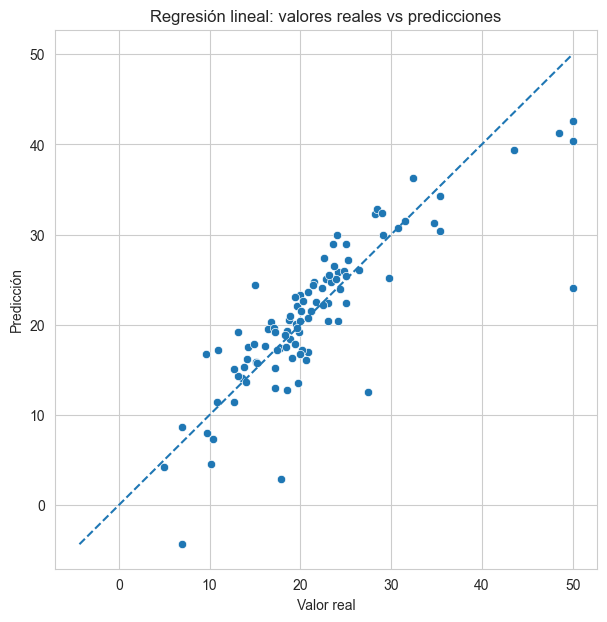

In [14]:
comparacion = pd.DataFrame({
    "real": y_test,
    "prediccion": pred_test_lineal
}).reset_index(drop=True)

display(comparacion.head(10))

plt.figure(figsize=(7, 7))
sns.scatterplot(data=comparacion, x="real", y="prediccion")
min_val = min(comparacion["real"].min(), comparacion["prediccion"].min())
max_val = max(comparacion["real"].max(), comparacion["prediccion"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Regresión lineal: valores reales vs predicciones")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.show()

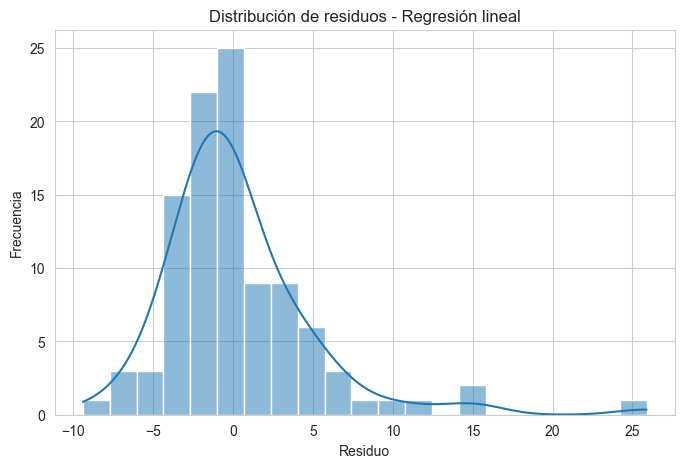

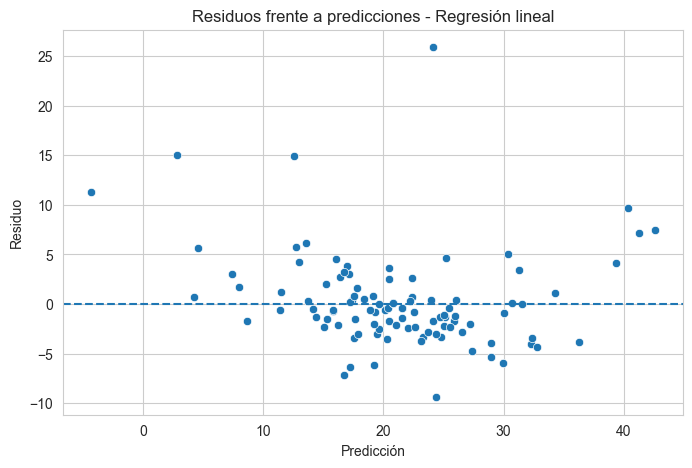

In [15]:
residuos = y_test - pred_test_lineal

plt.figure(figsize=(8, 5))
sns.histplot(residuos, kde=True)
plt.title("Distribución de residuos - Regresión lineal")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=pred_test_lineal, y=residuos)
plt.axhline(0, linestyle="--")
plt.title("Residuos frente a predicciones - Regresión lineal")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.show()